In [3]:
pip install pandas matplotlib seaborn plotly fhirclient

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [41]:
import pandas as pd

# Example: Load patient, claims, provider CSV files
patients_df = pd.read_csv('D:/Workspace/data/output_ie_galway_1k/csv/patients.csv')
claims_df = pd.read_csv('D:/Workspace/data/output_ie_galway_1k/csv/claims.csv')
transactions_df = pd.read_csv('D:/Workspace/data/output_ie_galway_1k/csv/claims_transactions.csv')
providers_df = pd.read_csv('D:/Workspace/data/output_ie_galway_1k/csv/providers.csv')
# Add other datasets as needed

print(patients_df.columns)
print(claims_df.columns)
print(transactions_df.columns)
print(providers_df.columns)

Index(['Id', 'BIRTHDATE', 'AGE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT',
       'PREFIX', 'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL',
       'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE',
       'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES',
       'HEALTHCARE_COVERAGE', 'INCOME'],
      dtype='object')
Index(['Id', 'PATIENTID', 'PROVIDERID', 'PRIMARYPATIENTINSURANCEID',
       'SECONDARYPATIENTINSURANCEID', 'DEPARTMENTID', 'PATIENTDEPARTMENTID',
       'DIAGNOSIS1', 'DIAGNOSIS2', 'DIAGNOSIS3', 'DIAGNOSIS4', 'DIAGNOSIS5',
       'DIAGNOSIS6', 'DIAGNOSIS7', 'DIAGNOSIS8', 'REFERRINGPROVIDERID',
       'APPOINTMENTID', 'CURRENTILLNESSDATE', 'SERVICEDATE',
       'SUPERVISINGPROVIDERID', 'STATUS1', 'STATUS2', 'STATUSP',
       'OUTSTANDING1', 'OUTSTANDING2', 'OUTSTANDINGP', 'LASTBILLEDDATE1',
       'LASTBILLEDDATE2', 'LASTBILLEDDATEP', 'HEALTHCARECLAIMTYPEID1',
       'HEALTHCARECLAIMTYPEID2'],
      dtype='object')
Index(['ID', 'C

In [67]:
#preprocessing

# Convert date columns to datetime
claims_df['SERVICEDATE'] = pd.to_datetime(claims_df['SERVICEDATE'], errors='coerce')
claims_df['LASTBILLEDDATE1'] = pd.to_datetime(claims_df['LASTBILLEDDATE1'], errors='coerce')
transactions_df['FROMDATE'] = pd.to_datetime(transactions_df['FROMDATE'], errors='coerce')
transactions_df['TODATE'] = pd.to_datetime(transactions_df['TODATE'], errors='coerce')

# Handle missing values
claims_df.fillna({'AMOUNT': 0}, inplace=True)
transactions_df.fillna({'AMOUNT': 0}, inplace=True)

print("Claims DataFrame columns:", claims_df.columns)
print("Transactions DataFrame columns:", transactions_df.columns)

Claims DataFrame columns: Index(['Id', 'PATIENTID', 'PROVIDERID', 'PRIMARYPATIENTINSURANCEID',
       'SECONDARYPATIENTINSURANCEID', 'DEPARTMENTID', 'PATIENTDEPARTMENTID',
       'DIAGNOSIS1', 'DIAGNOSIS2', 'DIAGNOSIS3', 'DIAGNOSIS4', 'DIAGNOSIS5',
       'DIAGNOSIS6', 'DIAGNOSIS7', 'DIAGNOSIS8', 'REFERRINGPROVIDERID',
       'APPOINTMENTID', 'CURRENTILLNESSDATE', 'SERVICEDATE',
       'SUPERVISINGPROVIDERID', 'STATUS1', 'STATUS2', 'STATUSP',
       'OUTSTANDING1', 'OUTSTANDING2', 'OUTSTANDINGP', 'LASTBILLEDDATE1',
       'LASTBILLEDDATE2', 'LASTBILLEDDATEP', 'HEALTHCARECLAIMTYPEID1',
       'HEALTHCARECLAIMTYPEID2'],
      dtype='object')
Transactions DataFrame columns: Index(['ID', 'CLAIMID', 'CHARGEID', 'PATIENTID', 'TYPE', 'AMOUNT', 'METHOD',
       'FROMDATE', 'TODATE', 'PLACEOFSERVICE', 'PROCEDURECODE', 'MODIFIER1',
       'MODIFIER2', 'DIAGNOSISREF1', 'DIAGNOSISREF2', 'DIAGNOSISREF3',
       'DIAGNOSISREF4', 'UNITS', 'DEPARTMENTID', 'NOTES', 'UNITAMOUNT',
       'TRANSFEROUTID',

In [85]:
# Cleansing

transactions_df.rename(columns={'ID': 'TRANSACTIONID'}, inplace=True)
transactions_df.rename(columns={'PROVIDERID': 'TRANS_PROVIDERID'}, inplace=True)
transactions_df.rename(columns={'PATIENTID': 'TRANS_PATIENTID'}, inplace=True)
transactions_df.rename(columns={'APPOINTMENTID': 'TRANS_APPOINTMENTID'}, inplace=True)
print(claims_df.columns.tolist())
print(transactions_df.columns.tolist())


['Id', 'PATIENTID', 'PROVIDERID', 'PRIMARYPATIENTINSURANCEID', 'SECONDARYPATIENTINSURANCEID', 'DEPARTMENTID', 'PATIENTDEPARTMENTID', 'DIAGNOSIS1', 'DIAGNOSIS2', 'DIAGNOSIS3', 'DIAGNOSIS4', 'DIAGNOSIS5', 'DIAGNOSIS6', 'DIAGNOSIS7', 'DIAGNOSIS8', 'REFERRINGPROVIDERID', 'APPOINTMENTID', 'CURRENTILLNESSDATE', 'SERVICEDATE', 'SUPERVISINGPROVIDERID', 'STATUS1', 'STATUS2', 'STATUSP', 'OUTSTANDING1', 'OUTSTANDING2', 'OUTSTANDINGP', 'LASTBILLEDDATE1', 'LASTBILLEDDATE2', 'LASTBILLEDDATEP', 'HEALTHCARECLAIMTYPEID1', 'HEALTHCARECLAIMTYPEID2']
['TRANSACTIONID', 'CLAIMID', 'CHARGEID', 'TRANS_PATIENTID', 'TYPE', 'AMOUNT', 'METHOD', 'FROMDATE', 'TODATE', 'PLACEOFSERVICE', 'PROCEDURECODE', 'MODIFIER1', 'MODIFIER2', 'DIAGNOSISREF1', 'DIAGNOSISREF2', 'DIAGNOSISREF3', 'DIAGNOSISREF4', 'UNITS', 'DEPARTMENTID', 'NOTES', 'UNITAMOUNT', 'TRANSFEROUTID', 'TRANSFERTYPE', 'PAYMENTS', 'ADJUSTMENTS', 'TRANSFERS', 'OUTSTANDING', 'TRANS_APPOINTMENTID', 'LINENOTE', 'PATIENTINSURANCEID', 'FEESCHEDULEID', 'TRANS_PROVIDE

In [93]:
# Merge claims and transactions on claims ID or CLAIMID for detailed analysis:

# Example merge (adjust as needed)
# If claims_df has 'ID' and transactions_df has 'CLAIMID'
merged_df = pd.merge(
    claims_df, 
    transactions_df, 
    left_on='Id', 
    right_on='CLAIMID', 
    how='left'
)

print(merged_df.columns)

Index(['Id', 'PATIENTID', 'PROVIDERID', 'PRIMARYPATIENTINSURANCEID',
       'SECONDARYPATIENTINSURANCEID', 'DEPARTMENTID_x', 'PATIENTDEPARTMENTID',
       'DIAGNOSIS1', 'DIAGNOSIS2', 'DIAGNOSIS3', 'DIAGNOSIS4', 'DIAGNOSIS5',
       'DIAGNOSIS6', 'DIAGNOSIS7', 'DIAGNOSIS8', 'REFERRINGPROVIDERID',
       'APPOINTMENTID', 'CURRENTILLNESSDATE', 'SERVICEDATE',
       'SUPERVISINGPROVIDERID_x', 'STATUS1', 'STATUS2', 'STATUSP',
       'OUTSTANDING1', 'OUTSTANDING2', 'OUTSTANDINGP', 'LASTBILLEDDATE1',
       'LASTBILLEDDATE2', 'LASTBILLEDDATEP', 'HEALTHCARECLAIMTYPEID1',
       'HEALTHCARECLAIMTYPEID2', 'TRANSACTIONID', 'CLAIMID', 'CHARGEID',
       'TRANS_PATIENTID', 'TYPE', 'AMOUNT', 'METHOD', 'FROMDATE', 'TODATE',
       'PLACEOFSERVICE', 'PROCEDURECODE', 'MODIFIER1', 'MODIFIER2',
       'DIAGNOSISREF1', 'DIAGNOSISREF2', 'DIAGNOSISREF3', 'DIAGNOSISREF4',
       'UNITS', 'DEPARTMENTID_y', 'NOTES', 'UNITAMOUNT', 'TRANSFEROUTID',
       'TRANSFERTYPE', 'PAYMENTS', 'ADJUSTMENTS', 'TRANSFERS', '

In [95]:
# Featute Engineering

#Create features indicative of suspicious behavior:

# 1. High claim amounts or high units:
# Outlier on claim amount
high_amount_threshold = merged_df['AMOUNT'].quantile(0.99)
suspect_high_amounts = merged_df[merged_df['AMOUNT'] > high_amount_threshold]


In [99]:

# 2. Frequent claims by the same provider or patient:
top_providers = merged_df['PROVIDERID'].value_counts().head(10)
top_patients = merged_df['PATIENTID'].value_counts().head(10)

# 3. Claims outside typical date ranges:
# e.g., claims with dates suspiciously outside the expected timeframe

# 4. Claims with unusual service codes or procedure codes:
suspicious_codes = ['XYZ123', 'ABC456']
suspect_codes_claims = merged_df[merged_df['PROCEDURECODE'].isin(suspicious_codes)]

# 5. Rapid claims from the same provider:
# Count claims per provider per day
merged_df['DATE'] = merged_df['SERVICEDATE'].dt.date
claims_per_provider_day = merged_df.groupby(['PROVIDERID', 'DATE']).size()
high_claim_freq = claims_per_provider_day[claims_per_provider_day > 10]



In [101]:
# Function to extract relevant patient info from FHIR JSON

def extract_patient_info(fhir_json):
    patient_info = {
        'id': fhir_json['id'],
        'name': fhir_json['name'][0]['text'],
        'gender': fhir_json['gender'],
        'birthDate': fhir_json.get('birthDate'),
        # add more fields as needed
    }
    return patient_info 

# Create DataFrame from FHIR data
#patients_fhir_df = pd.DataFrame([extract_patient_info(p) for p in fhir_data])

In [103]:
# Verify columns

print(patients_df.columns)

#print(patients_fhir_df.columns)

Index(['Id', 'BIRTHDATE', 'AGE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT',
       'PREFIX', 'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL',
       'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE',
       'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES',
       'HEALTHCARE_COVERAGE', 'INCOME'],
      dtype='object')


In [105]:
# Data cleansing
# Example: Convert 'birthDate' to datetime
patients_df['BIRTHDATE'] = pd.to_datetime(patients_df['BIRTHDATE'])
#patients_fhir_df['BIRTHDATE'] = pd.to_datetime(patients_fhir_df['BIRTHDATE'])

C:\Users\nithinmohan\AppData\Local\Temp\ipykernel_23920\499963955.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  patients_df['BIRTHDATE'] = pd.to_datetime(patients_df['BIRTHDATE'])


In [107]:
import datetime as dt
today = dt.date.today()

patients_df['AGE'] = patients_df['BIRTHDATE'].apply(
    lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day))
)
#patients_df['age'] = patients_df['BIRTHDATE'].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))

In [109]:
# Some Basic Analysis

print(patients_df.describe())
print(patients_df['AGE'].mean())

                           BIRTHDATE          AGE  FIPS          LAT  \
count                           1191  1191.000000   0.0  1191.000000   
mean   1980-04-09 19:44:53.198992448    44.540722   NaN    53.516870   
min              1914-12-21 00:00:00     0.000000   NaN    53.466764   
25%              1960-02-06 12:00:00    17.000000   NaN    53.491725   
50%              1979-07-08 00:00:00    45.000000   NaN    53.517960   
75%              2007-05-03 00:00:00    65.000000   NaN    53.542017   
max              2025-04-15 00:00:00   110.000000   NaN    53.566570   
std                              NaN    28.188140   NaN     0.028560   

               LON  HEALTHCARE_EXPENSES  HEALTHCARE_COVERAGE         INCOME  
count  1191.000000               1191.0         1.191000e+03    1191.000000  
mean     -8.850308                  0.0         7.106618e+05   26296.969773  
min      -8.899782                  0.0         6.220000e+02     173.000000  
25%      -8.874921                  0.0

In [111]:
#Debug

# Display top 50 records
print(patients_df.head(50))

                                      Id  BIRTHDATE  AGE   DEATHDATE  \
0   ef800789-eb74-1f5a-066b-61cbec8d62fe 2020-09-21    4         NaN   
1   e7026db0-bc62-65d2-d5de-ef2e600f4411 1985-09-05   39         NaN   
2   8f0cf403-bd0b-f5ef-0a89-9e75ff3a5f29 2022-02-05    3         NaN   
3   0a3d7f63-3eac-0f57-8f1b-2a06201bb721 2008-05-28   16         NaN   
4   902a34b4-64be-e9ff-bb2d-b753d553534e 2012-12-21   12         NaN   
5   448c124a-e3cb-473a-f405-7801a4bc34f2 2012-02-20   13         NaN   
6   27479cf4-5079-5433-5067-557694efa5ef 2007-10-02   17  04/02/2021   
7   f541b1ce-a938-492a-4f52-1b1fea5cb022 1976-05-25   48         NaN   
8   9a843484-bf02-feef-d0b8-d6394bb53ef2 1989-02-27   36         NaN   
9   643979e2-f932-6433-6fb6-3c3d8b9f2cf0 1970-01-20   55         NaN   
10  8d221591-8eab-704a-48d9-f7d8f2bfb63d 1980-03-28   45         NaN   
11  d9799e72-43bf-54be-186e-047f5be6bb0c 1975-11-03   49         NaN   
12  b665fe95-593c-7fd9-4428-365284336a68 2020-03-24    5        

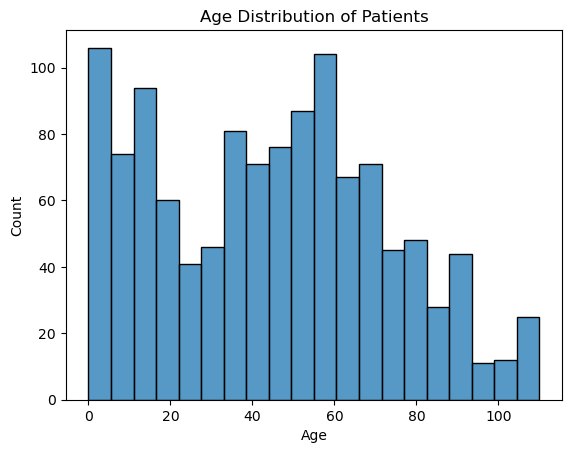

In [115]:
# Visualizations

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(patients_df['AGE'], bins=20)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

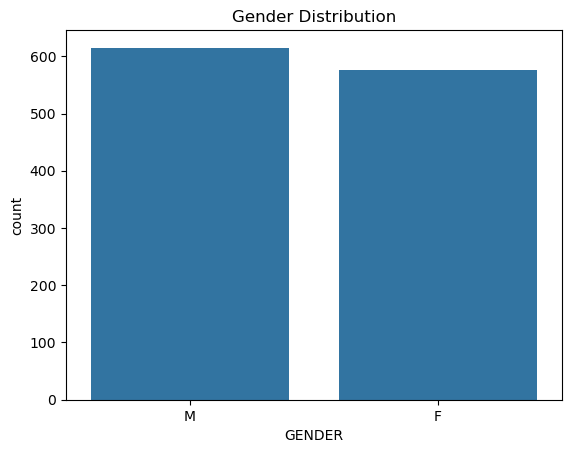

In [117]:
# Gender Distribution

sns.countplot(x='GENDER', data=patients_df)
plt.title('Gender Distribution')
plt.show()

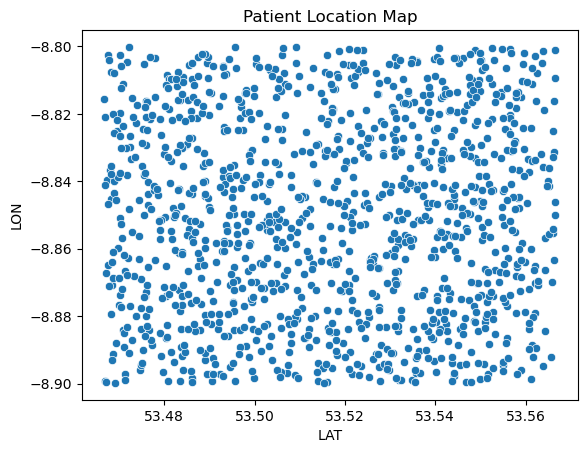

In [119]:
# Geographical Distribution
sns.scatterplot(x='LAT', y='LON', data=patients_df)
plt.title('Patient Location Map')
plt.show()

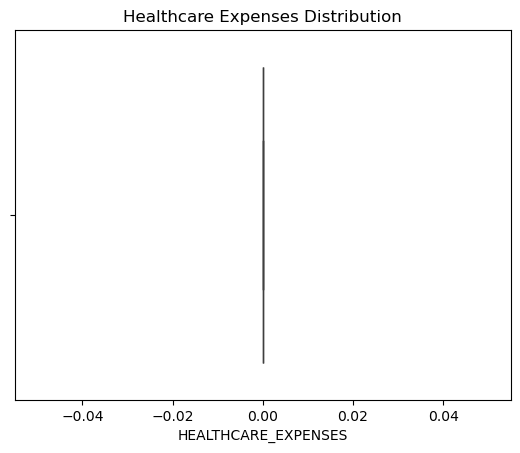

In [121]:
# Claims and Service Usage

sns.boxplot(x='HEALTHCARE_EXPENSES', data=patients_df)
plt.title('Healthcare Expenses Distribution')
plt.show()

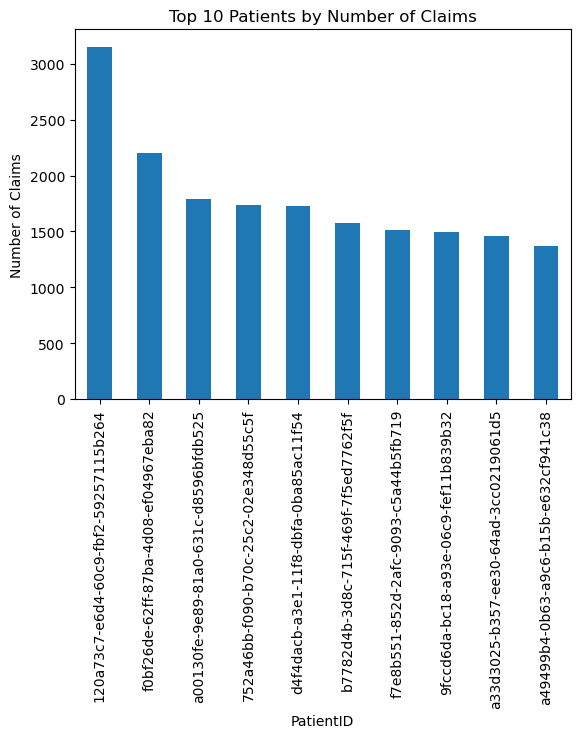

In [123]:
#Claims Analysis

import pandas as pd

# Total claims per patient
claims_per_patient = claims_df['PATIENTID'].value_counts()
top_patients = claims_per_patient.head(10)

# Plot top 10 patients with most claims
top_patients.plot(kind='bar')
plt.xlabel('PatientID')
plt.ylabel('Number of Claims')
plt.title('Top 10 Patients by Number of Claims')
plt.show()

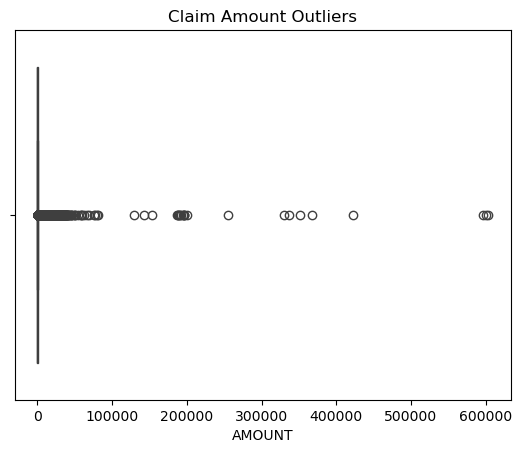

In [125]:
# ----------------------------------------------------
# |  Descriptive Statistics
# ----------------------------------------------------
# Summary of claim amounts per provider/member
# Distribution of claim frequencies per provider/member
# Identify outliers

# Example: Claim amount outliers
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=transactions_df['AMOUNT'])
plt.title('Claim Amount Outliers')
plt.show()

In [131]:
#Frequency and Pattern Analysis
#1. Count claims per provider, per patient, per diagnosis
#2. Detect unusually high claim counts or amounts

# Top providers by claim count
claims_per_provider = transactions_df['TRANS_PROVIDERID'].value_counts()
print(claims_per_provider.head(10))


TRANS_PROVIDERID
0d2e39ec-6723-37f1-ad2d-cb20fe0abab7    312218
3387010f-7f67-3f70-a2fa-27140012c519    118393
c0e6dbe2-d933-37eb-a4f9-dd5f662b11bf    105369
75f33711-8d92-3727-87d9-67e455ec2a08     37929
20c05f0e-0a6b-31f0-b282-f7186e4908be     35279
a8d655c4-8a15-3edf-babf-27e8f8ad3d10     15823
5edefc9f-0e3c-3f7f-b162-e5c5a60c00fa     14152
4b36b171-1e74-3e93-956e-842530dd9904      8607
Name: count, dtype: int64


In [133]:
# Anomoloy Detection 
# Use machine learning techniques such as Isolation Forest or Local Outlier Factor to find anomalous claims:
# 1. Prepare features (e.g., amount, units, claims count per provider/patient)
# 2. Encode categorical variables (provider, patient IDs)
# 3. Use IsolationForest or LocalOutlierFactor:

from sklearn.ensemble import IsolationForest
import numpy as np

# Example features
features = pd.DataFrame({
    'AMOUNT': merged_df['AMOUNT'],
    'UNITS': merged_df['UNITS'],
    # encode provider and patient IDs
    'PROVIDERID': merged_df['PROVIDERID'].astype('category').cat.codes,
    'PATIENTID': merged_df['PATIENTID'].astype('category').cat.codes
})

# Handling NaN
features.fillna(0, inplace=True)

# Fit IsolationForest
clf = IsolationForest(contamination=0.01, random_state=42)
merged_df['anomaly_score'] = clf.fit_predict(features)
suspect_claims = merged_df[merged_df['anomaly_score'] == -1]

In [35]:
# Define a high claim threshold, e.g., 99th percentile
high_claim_threshold = claims_trans_df['AMOUNT'].quantile(0.99)
suspicious_claims = claims_trans_df[claims_trans_df['AMOUNT'] > high_claim_threshold]
print(suspicious_claims)

                                          ID  \
124     a7c81d14-f49b-b131-37d2-c480ea3c8454   
164     bd0b327a-a187-5783-2759-33cf8f7884ca   
1583    16846e44-f284-5a7e-671d-76de58b24f21   
2117    c5f87959-660e-fca8-5ee3-192fc0c681e7   
2684    04946a8d-6b2b-4640-bcab-0548ded40b94   
...                                      ...   
645756  277b0046-23e4-b2d0-261d-95f9c0c189ff   
645764  47c965a0-91f2-008c-8183-13fe8f372bf3   
645802  8481db4f-c69e-50c6-0ed8-a9c5cad7c9c1   
646758  31d9eec8-60a1-f6b2-77bd-3926d60fcdeb   
646924  d08f155f-a44e-780a-8d7a-22ed84c4469f   

                                     CLAIMID  CHARGEID  \
124     c32eccb1-75e7-007e-a8b4-43ac96154dfb       186   
164     e3e11e34-6241-d88d-4f32-03f27b98ef48       248   
1583    c7013e74-9a06-3124-ecf4-f1f47cc59f60      2391   
2117    814c8ba4-58a8-f002-1ab2-716c8f88ab14      3216   
2684    c7f47e0a-1817-aec8-eb12-2271156bacaf      4083   
...                                      ...       ...   
645756  4641ab3e-

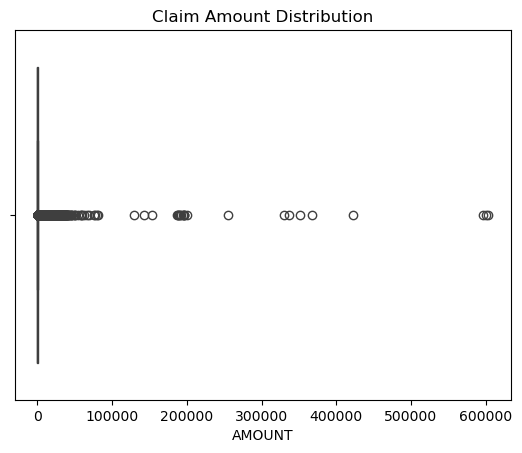

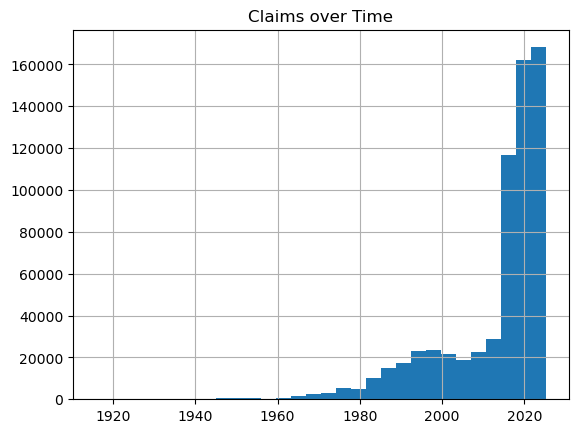

In [137]:
# Visualizations for FWA
# 1. Histograms of claim amounts to see outliers
# 2. Heatmaps of claim frequencies across geography
# 3. Network graphs of providers and patients involved in suspicious claims


import seaborn as sns
import matplotlib.pyplot as plt

# Plot claim amounts and claim frequency distributions:
sns.boxplot(x='AMOUNT', data=merged_df)
plt.title('Claim Amount Distribution')
plt.show()




In [ ]:

#Heatmaps of claim frequencies across geography
# Claims over time
merged_df['SERVICEDATE'].hist(bins=30)
plt.title('Claims over Time')
plt.show()

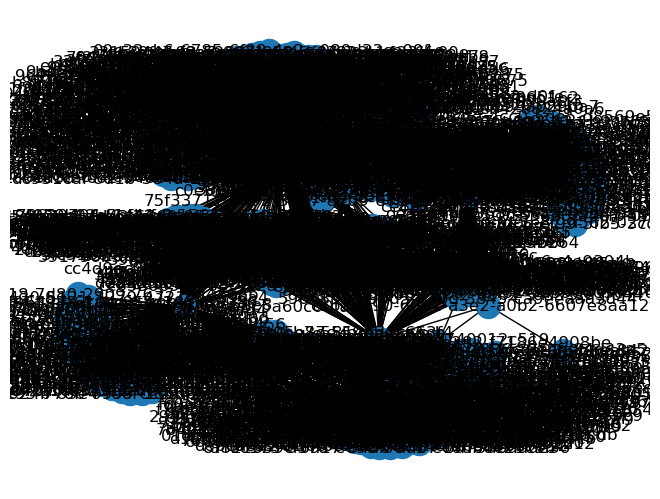

In [139]:
# Network graphs of providers and patients involved in suspicious claims
# Network Graphs of suspicious provider-patient interactions:

import networkx as nx

G = nx.Graph()
for _, row in suspect_claims.iterrows():
    G.add_node(row['PROVIDERID'], type='provider')
    G.add_node(row['PATIENTID'], type='patient')
    G.add_edge(row['PROVIDERID'], row['PATIENTID'])

nx.draw(G, with_labels=True)
plt.show()